In [48]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import matplotlib.pyplot as plt
%matplotlib inline

import torch.nn.functional as F
import random

In [66]:
words = open('names.txt', 'r').read().splitlines()
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [67]:
chars = sorted(list(set(''.join(words))))
mapp = {s:i+1 for i,s in enumerate(chars)}
mapp['.'] = 0
invmap = {i:s for s,i in mapp.items()}

In [113]:
block_size = 3
def build_dataset(words, bs):
    block_size = bs
    X,Y = [], []
    for w in words:
        #print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = mapp[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(invmap[i] for i in context), ' --> ', invmap[ix])
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

random.seed(222)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1], block_size)
Xdev, Ydev = build_dataset(words[n1:n2], block_size)
Xtst, Ytst = build_dataset(words[n2:], block_size)

In [119]:
#b1 is useless cause in hout - hout.mean() b1 cancels out since constant added value in mean gives that value back only hence cancels. So remove it

In [114]:
embspace = 10
n_hidden = 200

g = torch.Generator().manual_seed(222)
C = torch.randn((27, embspace), generator=g)
W1 = torch.randn((embspace*block_size, n_hidden), generator=g)  * 0.2 #(5/3)*((embspace*block_size)**(0.5)) #this is from research paper approxes 0.3 here
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, 27), generator=g) * 0.01
b2 = torch.randn(27, generator=g) * 0.0

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
for p in parameters:
    p.requires_grad = True

In [115]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    #minibatch
    mb = torch.randint(0, Xtr.shape[0], (batch_size,)) # selects random 32 rows from X 
    Xb = Xtr[mb]
    Yb = Ytr[mb]
    
    #Forward pass
    emb = C[Xb]
    emb = emb.view(emb.shape[0],embspace*block_size)
    hout = emb @ W1 + b1
    #since tanh kills very neg and ver pos values we will normalize it and make it roughly gaussion 
    bnmean = hout.mean(0, keepdim=True)
    bnstd = hout.std(0, keepdim=True)
    hout = (hout - bnmean)/ bnstd
    #now problem with always forcing it to be gaussian is it creates very similarities between diff neurons of a layer so dead neurons so we give soem bias and gaain to it
    hout = bngain*hout + bnbias

    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001*bnmean
        bnstd_running = 0.999 * bnstd_running + 0.001*bnstd
    
    h = torch.tanh(hout)
    logits = h@W2 + b2
    loss = F.cross_entropy(logits, Yb)

    lossi.append(loss.log10().item())
    if(i)%20000 == 0:
        print(loss.item())
        
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
        
    for p in parameters:
        p.data += -0.01 * p.grad

    #break

3.307044267654419
2.1997768878936768
2.330108165740967
1.9491897821426392
2.231584310531616
2.3448169231414795
2.3400838375091553
2.4414889812469482
2.0716490745544434
2.100970506668091


In [88]:
#plt.hist(h.view(-1).tolist(), 50);

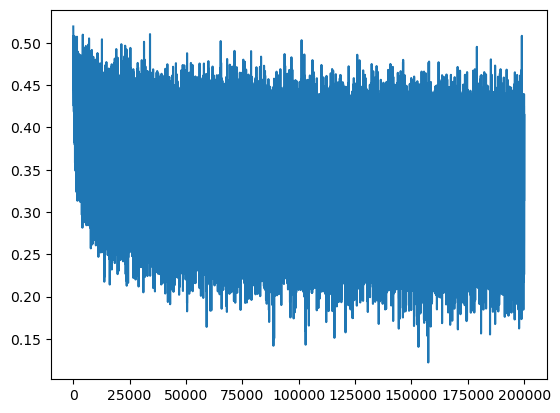

In [116]:
plt.plot(lossi)

In [117]:
Xs = [Xtr, Xdev, Xtst]
Ys = [Ytr, Ydev, Ytst]

@torch.no_grad()
def func():
    for x,y in zip(Xs, Ys):
        emb = C[x]
        emb = emb.view(emb.shape[0], embspace*block_size)
        hout = emb @ W1 + b1
        hout = (hout - bnmean_running)/ bnstd_running
        hout = bngain*hout + bnbias
        h = torch.tanh(hout)
        logits = h@W2 + b2
        loss = F.cross_entropy(logits, y)
        print(f"-tr/dev/tst: {loss.item()}")

func()

-tr/dev/tst: 2.1161320209503174
-tr/dev/tst: 2.146688938140869
-tr/dev/tst: 2.1433844566345215


In [118]:
# Sampling from the neural network
g = torch.Generator().manual_seed(222)

for _ in range(20):
    out = []
    context = [0] * block_size 
    
    while True:
        emb = C[torch.tensor([context])]
        emb = emb.view(1, 30)
        hout = emb @ W1 + b1
        hout = (hout - bnmean_running)/ bnstd_running
        hout = bngain*hout + bnbias
        h = torch.tanh(hout)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        
        context = context[1:] + [ix]
        out.append(ix)
        
        if ix == 0:
            break

    print(''.join(invmap[i] for i in out))

nevic.
zyalfyro.
damaycidahtib.
ran.
vidoly.
jeli.
anjalis.
cruq.
emile.
ayleah.
tamelma.
jalia.
zulanie.
hon.
kenia.
mari.
jamiah.
blishan.
avinca.
ham.
